# T010 · 结合位点相似性与脱靶预测

**注意：** 本教程是 TeachOpenCADD 的一部分，该平台旨在教授特定领域技能，并为研究项目提供管道模板作为起点。

作者：

- Dominique Sydow, 2019-2020, [Volkamer lab, Charité](https://volkamerlab.org/)
- Andrea Volkamer, 2020, [Volkamer lab, Charité](https://volkamerlab.org/)
- Yonghui Chen, 2020, [Volkamer lab, Charité](https://volkamerlab.org/)

__教程 T010__：本教程是 [首篇 TeachOpenCADD 论文](https://jcheminf.biomedcentral.com/articles/10.1186/s13321-019-0351-x) 中描述的 TeachOpenCADD 流程的一部分，包括 T001-T010 教程。

**注意**：请逐个单元格运行本 notebook。也可以一次运行所有单元格，但执行某些单元格可能需要几秒钟。

## 本教程目标

在本教程中，我们使用完整蛋白质及其结合位点的结构相似性来识别已知抑制剂的可能脱靶蛋白。

### 理论内容

* 脱靶蛋白
* 计算脱靶预测：结合位点比较
* 成对 RMSD 作为相似性的简单度量
* Imatinib，一种酪氨酸激酶抑制剂

### 实践内容

* 加载并可视化感兴趣的配体（Imatinib/STI）
* 从 PDB 获取所有蛋白-STI 复合物
* 可视化 PDB 结构
* 对齐 PDB 结构（完整蛋白质）
* 获取成对 RMSD（完整蛋白质）
* 对齐 PDB 结构（结合位点）
* 获取成对 RMSD（结合位点）
* 过滤异常值

### 参考文献

* 结合位点叠加和比较
    * 结合位点比较综述：
        * [<i>J. Med. Chem.</i> (2016), <b>59</b>, 4121-4151](https://pubs.acs.org/doi/abs/10.1021/acs.jmedchem.6b00078)
        * [<i>Proteins</i> (2008), <b>71</b>, 910-919](https://onlinelibrary.wiley.com/doi/abs/10.1002/prot.21775)
    * PDB 中与 Imatinib 共晶化的蛋白：
        * [<i>J. Med. Chem.</i> (2016), <b>383</b>, 188-97](https://www.ncbi.nlm.nih.gov/pubmed/27181305)
* Imatinib
    * [Imatinib (Wikipedia)](https://en.wikipedia.org/wiki/Imatinib) 和 [FDA 标签](https://www.accessdata.fda.gov/drugsatfda_docs/label/2008/021588s024lbl.pdf)
    * [<i>Nat. Rev. Cancer</i> (2007), <b>7</b>, 345-356](https://www.nature.com/articles/nrc2123)

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install teachopencadd --no-deps -q
    !teachopencadd -d 10
    %pip uninstall teachopencadd -y -q
    %pip install -qr requirements.txt

## 理论

### 脱靶蛋白

脱靶可以是与药物或其代谢物相互作用的任何蛋白质，能够产生未预期的治疗效果或副作用。因此，预测可能的脱靶有助于更好地了解副作用，并为设计选择性（因此更安全）的药物提供更好的起点。事实上，一种给定的药物可能已被证明对多种疾病有疗效，这归因于脱靶效应。

### 计算脱靶预测：结合位点比较

计算辅助预测可能的脱靶的一种方法是比较感兴趣蛋白质的结合位点与数据库中蛋白质的结合位点。
如果两个结合位点在结构上相似，我们可以推断另一种蛋白质是可能的脱靶。

### 成对 RMSD 作为相似性的简单度量

评分相似性的一个简单直接的方法是在结构叠加后计算两个结合位点之间的成对 RMSD。然而，更复杂的方法也存在，如在**教程 T025**中介绍的 KiSSim 指纹。

### Imatinib，一种酪氨酸激酶抑制剂

激酶将 ATP 的磷酸基团转移到蛋白质上，这一过程称为磷酸化。这个过程是许多细胞信号转导途径的核心。激酶抑制剂因此被开发为抗癌药物，因为癌细胞生长通常由失调的激酶活性驱动。Imatinib 是第一个 FDA 批准的小分子蛋白激酶抑制剂，是一种抗癌药物；最初用于慢性粒细胞白血病，很快扩展到更多类型的癌症。

它的主要靶标是 Abl1（Abelson murine leukemia viral oncogene homolog 1，也称为 ABL），但也靶向其他激酶，如 KIT、PDGFR 和 DDR。

## 实践

接下来，我们将获取并筛选与 Imatinib 结合的 PDB 结构。我们将首先对齐完整蛋白质，然后对齐结合位点，并比较 RMSD 以检测异常值。

In [2]:
import logging
from pathlib import Path
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import redo
import nglview as nv
import pypdb
import biotite.database.rcsb as rcsb
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from MDAnalysis.analysis import rms
from opencadd.structure.core import Structure
from opencadd.structure.superposition.api import align, METHODS
from opencadd.structure.superposition.engines.mda import MDAnalysisAligner

SEED = 22
np.random.seed(SEED)
random.seed(SEED)

In [3]:
# Ignore warnings, added because of the two following warnings
# VisibleDeprecationWarning (MDAnalysis), ClusterWarning (seaborn)
# TODO check in the future if ignoring warnings is still necessary
warnings.simplefilter("ignore")
# Also make MDAnalysis code in OpenCADD a bit less noisy
logger = logging.getLogger("opencadd")
logger.setLevel(logging.ERROR)

In [4]:
# 设置本 notebook 的路径
HERE = Path(_dh[0])
DATA = HERE / "data"

In [5]:
# Frozen set of PDB IDs that will be used in this notebook
# TODO check in the future if we want to update this dataset
FROZEN_PDB_IDS = ["3HEC", "2PL0", "4CSV", "4R7I", "1XBB", "3FW1", "1T46"]

### 加载并可视化感兴趣的配体（Imatinib/STI）

Imatinib 的 SMILES 格式可以从 PDB 中的配体条目获取。我们将 Imatinib 的三个字母代码 STI 映射到其 SMILES 表示。

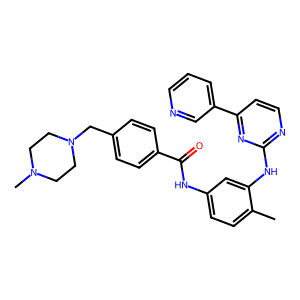

In [6]:
smiles = Chem.MolFromSmiles("CN1CCN(Cc2ccc(cc2)C(=O)Nc2ccc(C)c(Nc3nccc(n3)-c3cccnc3)c2)CC1")
Draw.MolToImage(smiles)

为了检查 STI 的三维结构，我们使用开源工具 `nglview`。在我们可以可视化 3D 坐标之前，我们需要为配体生成 3D 坐标。

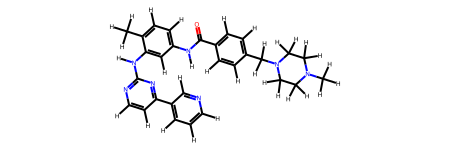

In [7]:
molecule = Chem.AddHs(smiles)
molecule

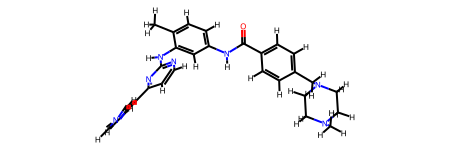

In [8]:
AllChem.EmbedMolecule(molecule)
AllChem.UFFOptimizeMolecule(molecule)
molecule

现在，我们准备好在 `nglview` 中展示了！

In [9]:
view = nv.show_rdkit(molecule)
view

NGLWidget()

In [10]:
view.render_image(trim=True, factor=2, transparent=True);

In [11]:
view._display_image()

### 从 PDB 获取蛋白质-STI 复合物

接下来，我们将搜索描述 Imatinib/STI 与蛋白质共晶化的 PDB ID。我们使用 `biotite` 包中的 FieldQuery，如**教程 T008**所述。

我们筛选以下条件：
- 包含 STI（作为配体）的结构
- 通过 X 射线晶体学解析的结构
- 分辨率 ≤ 3.0 Å 的结构
- 仅有一条链的结构

**查询与 STI 结合的结构**

In [12]:
query_by_ligand_id = rcsb.FieldQuery(
    "rcsb_nonpolymer_entity_container_identifiers.nonpolymer_comp_id", exact_match="STI"
)
print(f"Number of matches: {rcsb.count(query_by_ligand_id)}")

Number of matches: 29


**查询通过 X 射线晶体学解析的结构**

In [13]:
query_by_experimental_method = rcsb.FieldQuery("exptl.method", exact_match="X-RAY DIFFRACTION")
print(f"Number of matches: {rcsb.count(query_by_experimental_method)}")

Number of matches: 200337


**查询分辨率小于等于 3.0 的结构**

In [14]:
query_by_resolution = rcsb.FieldQuery("rcsb_entry_info.resolution_combined", less_or_equal=3.0)
print(f"Number of matches: {rcsb.count(query_by_resolution)}")

Number of matches: 197276


**查询仅有一条链的结构**

In [15]:
query_by_polymer_count = rcsb.FieldQuery(
    "rcsb_entry_info.deposited_polymer_entity_instance_count", equals=1
)
print(f"Number of matches: {rcsb.count(query_by_polymer_count)}")

Number of matches: 85341


**查询满足以上所有条件的结构**

使用 `and` 运算符组合查询列表。

In [16]:
query = rcsb.CompositeQuery(
    [
        query_by_ligand_id,
        query_by_experimental_method,
        query_by_resolution,
        query_by_polymer_count,
    ],
    "and",
)
pdb_ids = rcsb.search(query)
print(f"Number of matches: {len(pdb_ids)}")
print("Selected PDB IDs:")
print(*pdb_ids)

Number of matches: 9
Selected PDB IDs:
1T46 1XBB 2PL0 3FW1 3GVU 3HEC 4CSV 4R7I 6JOL


In [17]:
pdb_ids

['1T46', '1XBB', '2PL0', '3FW1', '3GVU', '3HEC', '4CSV', '4R7I', '6JOL']

__注意__：下一步仅出于技术原因。为了自动维护 notebook，我们定义了一个包含最后结果 PDB ID 的冻结集合。如有疑问，请注释掉冻结单元格。

In [18]:
pdb_ids = FROZEN_PDB_IDS
print("Final set of PDB IDs:")
print(*pdb_ids)

Final set of PDB IDs:
3HEC 2PL0 4CSV 4R7I 1XBB 3FW1 1T46


### 可视化 PDB 结构

首先，我们在 `nglview` 中加载所有结构以进行可视化检查。

In [19]:
view = nv.NGLWidget()
for pdb_id in pdb_ids:
    view.add_pdbid(pdb_id)
view

NGLWidget()

In [20]:
view.render_image(trim=True, factor=2, transparent=True);

In [21]:
view._display_image()

虽然这张图像色彩丰富且曲线优美，但还不够信息丰富。我们将在接下来的步骤中对齐结构。

In [22]:
# Download PDB
structures = [Structure.from_pdbid(pdb_id) for pdb_id in pdb_ids]
# Strip solvent and other artifacts of crystallography
proteins = [Structure.from_atomgroup(s.select_atoms("protein")) for s in structures]
# Align proteins
results = align(proteins, method=METHODS["mda"])

In [23]:
proteins

[<Universe with 2684 atoms>,
 <Universe with 2182 atoms>,
 <Universe with 1968 atoms>,
 <Universe with 2269 atoms>,
 <Universe with 2124 atoms>,
 <Universe with 3648 atoms>,
 <Universe with 2381 atoms>]

### 对齐 PDB 结构（完整蛋白质）

我们将使用 `opencadd` 包中的一个（`structure.superposition` 模块）来对齐结构。
- 对所有结构的第一个结构进行成对序列对齐
- 基于匹配残基的成对结构叠加

In [24]:
Structure.from_pdbid("4YNE")

<Universe with 2334 atoms>

In [25]:
view = nv.NGLWidget()
for protein in proteins:
    view.add_component(protein.atoms)
view

NGLWidget()

In [26]:
view.render_image(trim=True, factor=2, transparent=True);

In [27]:
view._display_image()

许多螺旋的结构对齐度很高，而其他蛋白质部分的对齐度较低或较差。

In [28]:
def calc_rmsd(A, B):
    """
    Calculate RMSD between two structures.

    Parameters
    ----------
    A : opencadd.structure.core.Structure
        Structure A.
    B : opencadd.structure.core.Structure
        Structure B.

    Returns
    -------
    float
        RMSD value.
    """
    aligner = MDAnalysisAligner()
    selection, _ = aligner.matching_selection(A, B)
    A = A.select_atoms(selection["reference"])
    B = B.select_atoms(selection["mobile"])
    return rms.rmsd(A.positions, B.positions, superposition=False)

In [29]:
def calc_rmsd_matrix(structures, names):
    """
    Calculate RMSD matrix between a list of structures.

    Parameters
    ----------
    structures : list of opencadd.structure.core.Structure
        List of structures.
    names : list of str
        List of structure names.

    Returns
    -------
    pandas.DataFrame
        RMSD matrix.
    """
    values = {name: {} for name in names}
    for i, (A, name_i) in enumerate(zip(structures, names)):
        for j, (B, name_j) in enumerate(zip(structures, names)):
            if i == j:
                values[name_i][name_j] = 0.0
                continue
            if i < j:
                rmsd = calc_rmsd(A, B)
                values[name_i][name_j] = rmsd
                values[name_j][name_i] = rmsd
                continue
    df = pd.DataFrame.from_dict(values)
    return df

### 获取成对 RMSD（完整蛋白质）

In [30]:
# NBVAL_CHECK_OUTPUT
rmsd_matrix = calc_rmsd_matrix(proteins, pdb_ids)
rmsd_matrix.round(1)

,3HEC,2PL0,4CSV,4R7I,1XBB,3FW1,1T46
3HEC,0.0,16.1,12.6,20.5,17.3,23.7,20.4
2PL0,16.1,0.0,3.7,13.5,7.6,22.8,16.4
4CSV,12.6,3.7,0.0,14.0,7.8,22.5,16.7
4R7I,20.5,13.5,14.0,0.0,11.8,21.9,8.0
1XBB,17.3,7.6,7.8,11.8,0.0,22.3,14.3
3FW1,23.7,22.8,22.5,21.9,22.3,0.0,21.4
1T46,20.4,16.4,16.7,8.0,14.3,21.4,0.0


我们将此 RMSD 精修结果可视化为热图。

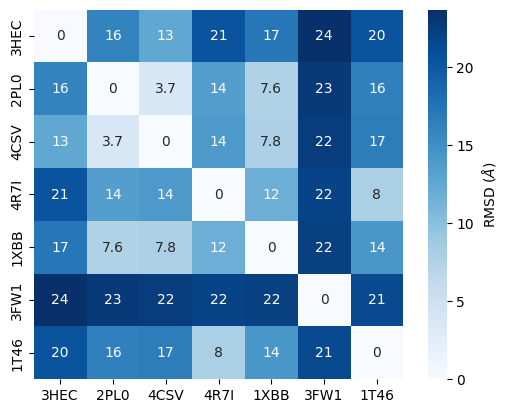

In [31]:
# Make sure matplotlib version >= 3.1.2; otherwise you'll get Y-cropped heatmaps
sns.heatmap(
    rmsd_matrix,
    linewidths=0,
    annot=True,
    square=True,
    cbar_kws={"label": "RMSD ($\AA$)"},
    cmap="Blues",
);

我们对热图进行聚类，以便基于 RMSD 精修看到蛋白质相似性。

In [32]:
def plot_clustermap(rmsd):
    """
    Plot clustered heatmap from import RMSD matrix.

    Parameters
    ----------
    rmsd : pandas.DataFrame
        RMSD matrix.
    title : str
        Plot title.

    Returns
    -------
    matplotlib.figure.Figure
        Clustered heatmap.
    """
    g = sns.clustermap(
        rmsd,
        linewidths=1,
        annot=True,
        cbar_kws={"label": "RMSD ($\AA$)"},
        cmap="Blues",
    )
    plt.setp(g.ax_heatmap.get_xticklabels(), rotation=0)
    plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)
    sns.set(font_scale=1.5)
    return plt.gcf()

In [33]:
rmsd_matrix

,3HEC,2PL0,4CSV,4R7I,1XBB,3FW1,1T46
3HEC,0.000000,16.091148,12.589473,20.523115,17.263280,23.672817,20.421263
2PL0,16.091148,0.000000,3.723816,13.514326,7.557453,22.814496,16.381494
4CSV,12.589473,3.723816,0.000000,14.013465,7.848997,22.471284,16.651349
4R7I,20.523115,13.514326,14.013465,0.000000,11.819335,21.941547,7.951605
1XBB,17.263280,7.557453,7.848997,11.819335,0.000000,22.256707,14.331909
3FW1,23.672817,22.814496,22.471284,21.941547,22.256707,0.000000,21.429275
1T46,20.421263,16.381494,16.651349,7.951605,14.331909,21.429275,0.000000


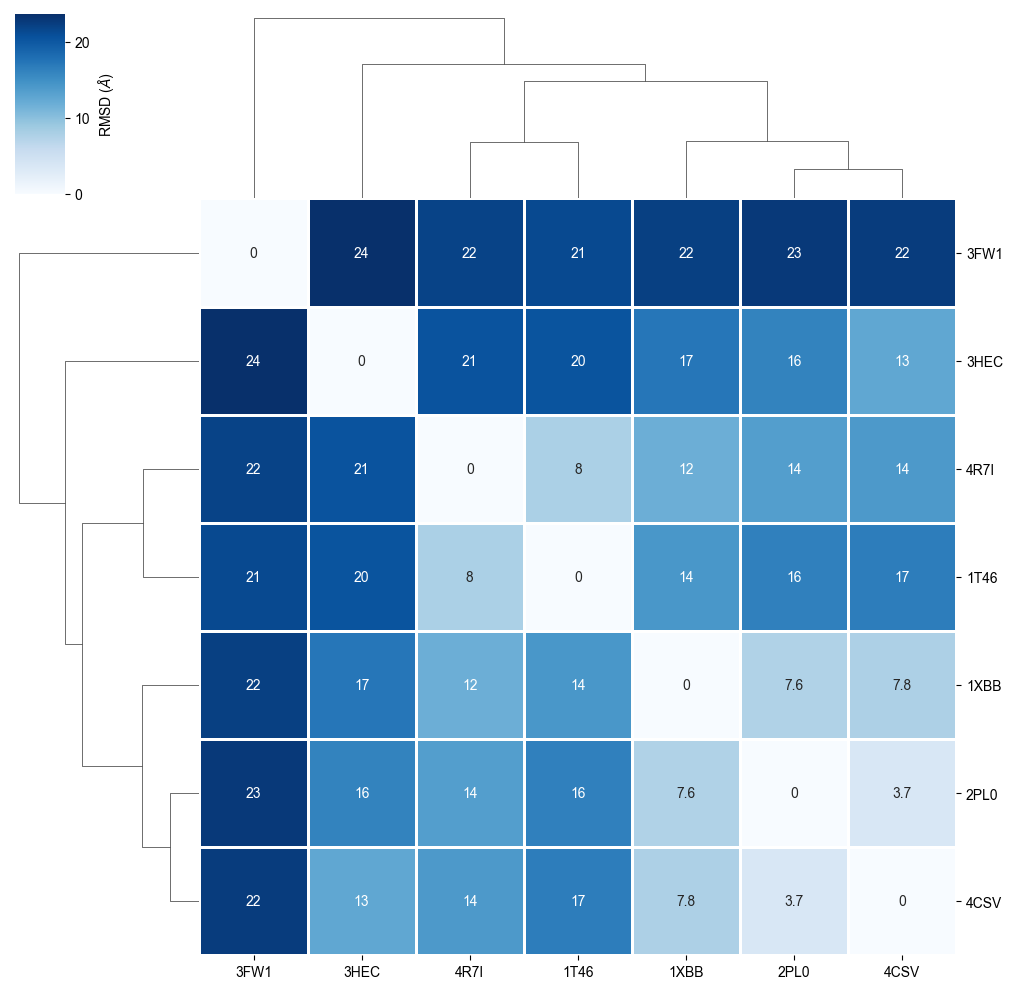

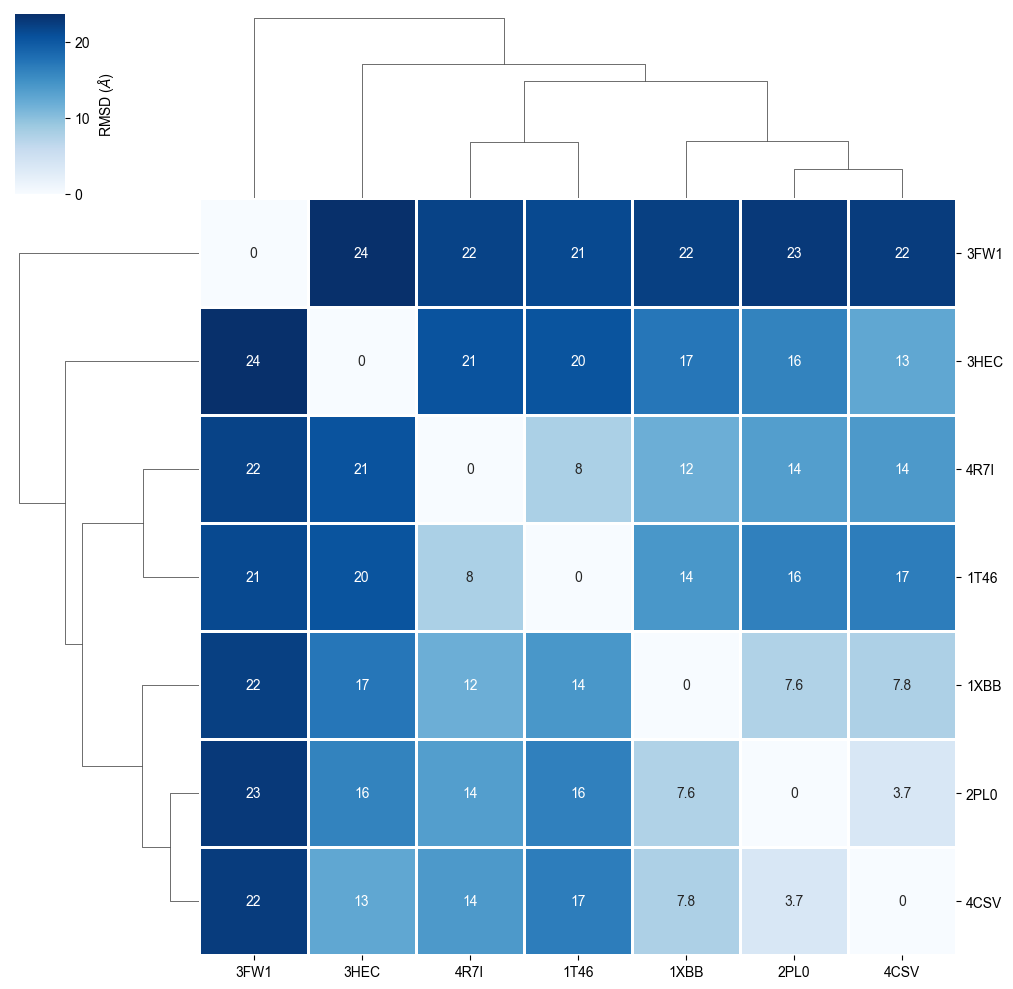

In [34]:
plot_clustermap(rmsd_matrix)

In [35]:
# Check the shape of the matrix
print(f"RMSD Matrix Shape: {rmsd_matrix.shape}")

# Check for non-finite values (NaN, Inf)
print(f"Number of non-finite values: {rmsd_matrix.isna().sum().sum()}")

# Display the matrix head
print(rmsd_matrix.head())

RMSD Matrix Shape: (7, 7)
Number of non-finite values: 0
           3HEC       2PL0       4CSV       4R7I       1XBB       3FW1  \
3HEC   0.000000  16.091148  12.589473  20.523115  17.263280  23.672817   
2PL0  16.091148   0.000000   3.723816  13.514326   7.557453  22.814496   
4CSV  12.589473   3.723816   0.000000  14.013465   7.848997  22.471284   
4R7I  20.523115  13.514326  14.013465   0.000000  11.819335  21.941547   
1XBB  17.263280   7.557453   7.848997  11.819335   0.000000  22.256707   

           1T46  
3HEC  20.421263  
2PL0  16.381494  
4CSV  16.651349  
4R7I   7.951605  
1XBB  14.331909  


RMSD 比较显示一种蛋白质与其他蛋白质差异最大，即 3FW1。让我们尝试找出此异常值可能由什么引起。

蛋白质通过其催化的化学反应进行分类，使用 EC（酶委员会）编号，这些信息作为元信息保存在 PDB 结构中。

In [36]:
# NBVAL_CHECK_OUTPUT
# Get EC numbers for PDB IDs from PDB
pdbs_info = [pypdb.get_all_info(pdb_id) for pdb_id in pdb_ids]
# latest versions of the PDB API changed "pdbx_descriptor" to "title"
pdbx_descriptors = [pdb_info["struct"]["title"] for pdb_info in pdbs_info]
ec_numbers = pd.DataFrame(
    {
        "pdb_id": pdb_ids,
        "description": pdbx_descriptors,
    }
)
# Increase column width to fit all text
pd.set_option("max_colwidth", 100)
ec_numbers

,pdb_id,description
0,3HEC,P38 in complex with Imatinib
1,2PL0,LCK bound to imatinib
2,4CSV,Tyrosine kinase AS - a common ancestor of Src and Abl bound to Gleevec
3,4R7I,"Crystal structure of FMS kinase domain with a small molecular inhibitor, GLEEVEC"
4,1XBB,Crystal structure of the syk tyrosine kinase domain with Gleevec
5,3FW1,Quinone Reductase 2
6,1T46,STRUCTURAL BASIS FOR THE AUTOINHIBITION AND STI-571 INHIBITION OF C-KIT TYROSINE KINASE


我们可以看到 3FW1 是人醌还原酶 2（NQO2），是这些蛋白质中唯一不属于激酶类（EC 2.7.-.-）的蛋白质，而所有其他蛋白质都是激酶。尽管 Imatinib 还与 NQO2 结合，但这一结果表明 Imatinib 的结合姿势可能与其他研究中的激酶不同。

### 对齐 PDB 结构（结合位点）

到目前为止，我们使用了完整的蛋白质结构进行对齐和 RMSD 精修。然而，配体结合于结合位点，这就是配体相似性（因此脱靶可能性）最相关的地方。我们现在将仅对齐结合位点区域，并观察 RMSD 精修对此子结构的效果如何。

In [37]:
sel = "same residue as (resname STI or (around 10 resname STI))"
binding_sites = [Structure.from_atomgroup(s.select_atoms(sel)) for s in structures]

让我们仅查看蛋白质的结合位点。

In [38]:
view = nv.NGLWidget()
for binding_site in binding_sites:
    view.add_component(binding_site.atoms)
view

NGLWidget()

In [39]:
view.render_image(trim=True, factor=2, transparent=True);

In [40]:
view._display_image()

现在我们对齐结合位点。

In [41]:
results_binding_sites = align(binding_sites, method=METHODS["mda"])

让我们可视化我们对齐的结合位点。

In [42]:
view = nv.NGLWidget()
for binding_site in binding_sites:
    view.add_component(binding_site.atoms)
view

NGLWidget()

In [43]:
view.render_image(trim=True, factor=2, transparent=True);

In [44]:
view._display_image()

### 获取成对 RMSD（结合位点）

In [45]:
# NBVAL_CHECK_OUTPUT
rmsd_matrix_binding_sites = calc_rmsd_matrix(binding_sites, pdb_ids)
rmsd_matrix_binding_sites.round(1)

,3HEC,2PL0,4CSV,4R7I,1XBB,3FW1,1T46
3HEC,0.0,6.2,3.3,5.7,12.3,15.0,9.8
2PL0,6.2,0.0,4.5,4.0,11.7,11.3,4.3
4CSV,3.3,4.5,0.0,5.6,10.7,14.3,6.3
4R7I,5.7,4.0,5.6,0.0,10.5,14.5,2.7
1XBB,12.3,11.7,10.7,10.5,0.0,13.5,11.1
3FW1,15.0,11.3,14.3,14.5,13.5,0.0,15.3
1T46,9.8,4.3,6.3,2.7,11.1,15.3,0.0


我们展示 RMSD 结果的聚类热图。

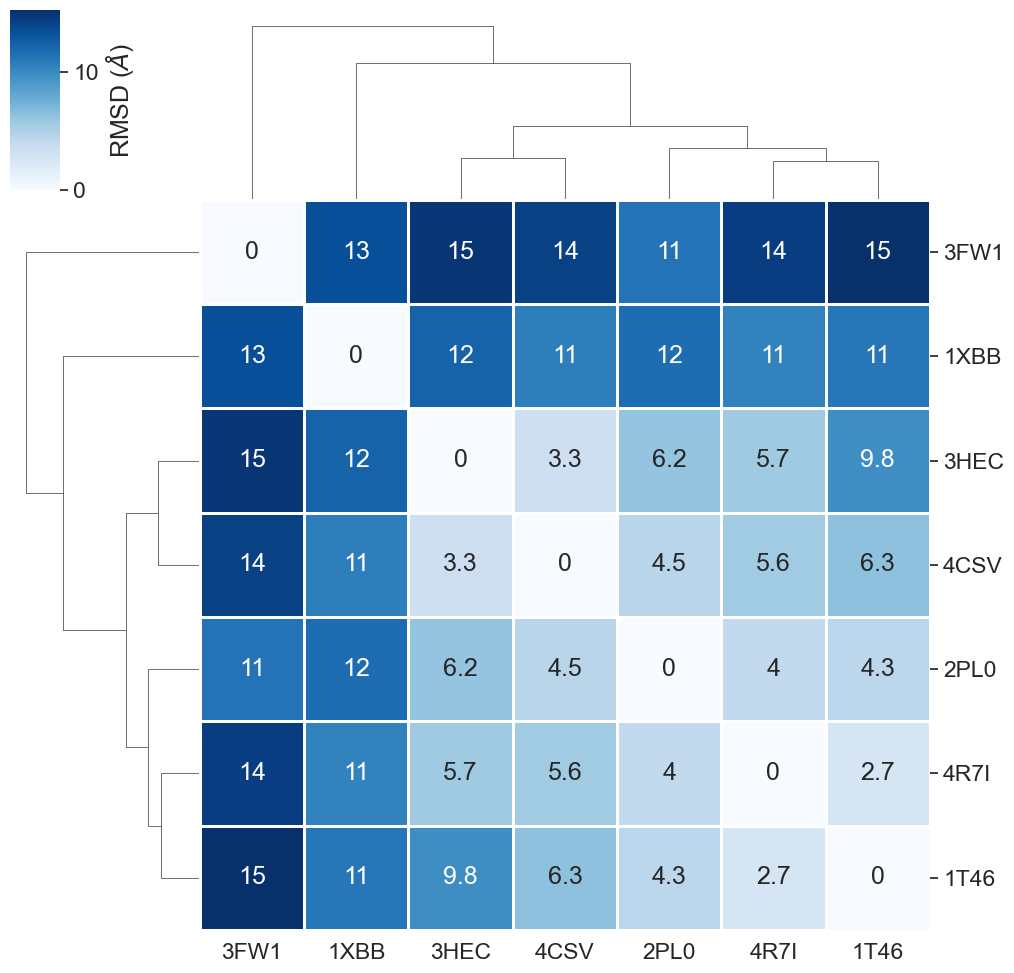

In [46]:
# Show the pairwise RMSD values as clustered heatmap
plot_clustermap(rmsd_matrix_binding_sites);

此热图中的关键观察是什么？
- 正如在*完整蛋白质*比较中已经观察到的，3FW1 在结合位点上也与所有其他蛋白质不同。
- 有趣的是，在*结合位点*水平上，其他蛋白质的相似性比在*完整蛋白质*水平上低得多。因此，结合位点相似性是对将靶标视为脱靶更严格的测试。

### 过滤异常值

为了更清晰地展示最相似的结构，我们可以过滤 `3FW1`（NQO2）。

In [47]:
filtered_structures = []
filtered_pdb_ids = []
for name, structure in zip(pdb_ids, structures):
    if name not in ("3FW1", "1XBB"):
        filtered_structures.append(structure)
        filtered_pdb_ids.append(name)

In [48]:
selection = "same residue as (resname STI or (around 10 resname STI))"
filtered_binding_sites = [
    Structure.from_atomgroup(s.select_atoms(selection)) for s in filtered_structures
]

In [49]:
view = nv.NGLWidget()
for binding_site in filtered_binding_sites:
    view.add_component(binding_site.atoms)
view

NGLWidget()

In [50]:
view.render_image(trim=True, factor=2, transparent=True);

In [51]:
view._display_image()

In [52]:
filtered_results_binding_sites = align(filtered_binding_sites, method=METHODS["mda"])

In [53]:
view = nv.NGLWidget()
for binding_site in filtered_binding_sites:
    view.add_component(binding_site.atoms)
view

NGLWidget()

In [54]:
view.render_image(trim=True, factor=2, transparent=True);

In [55]:
view._display_image()

In [56]:
# NBVAL_CHECK_OUTPUT
filtered_rmsd_matrix_bs = calc_rmsd_matrix(filtered_binding_sites, filtered_pdb_ids)
filtered_rmsd_matrix_bs.round(1)

,3HEC,2PL0,4CSV,4R7I,1T46
3HEC,0.0,6.2,3.3,5.7,9.8
2PL0,6.2,0.0,4.5,4.0,4.3
4CSV,3.3,4.5,0.0,5.6,6.3
4R7I,5.7,4.0,5.6,0.0,2.7
1T46,9.8,4.3,6.3,2.7,0.0


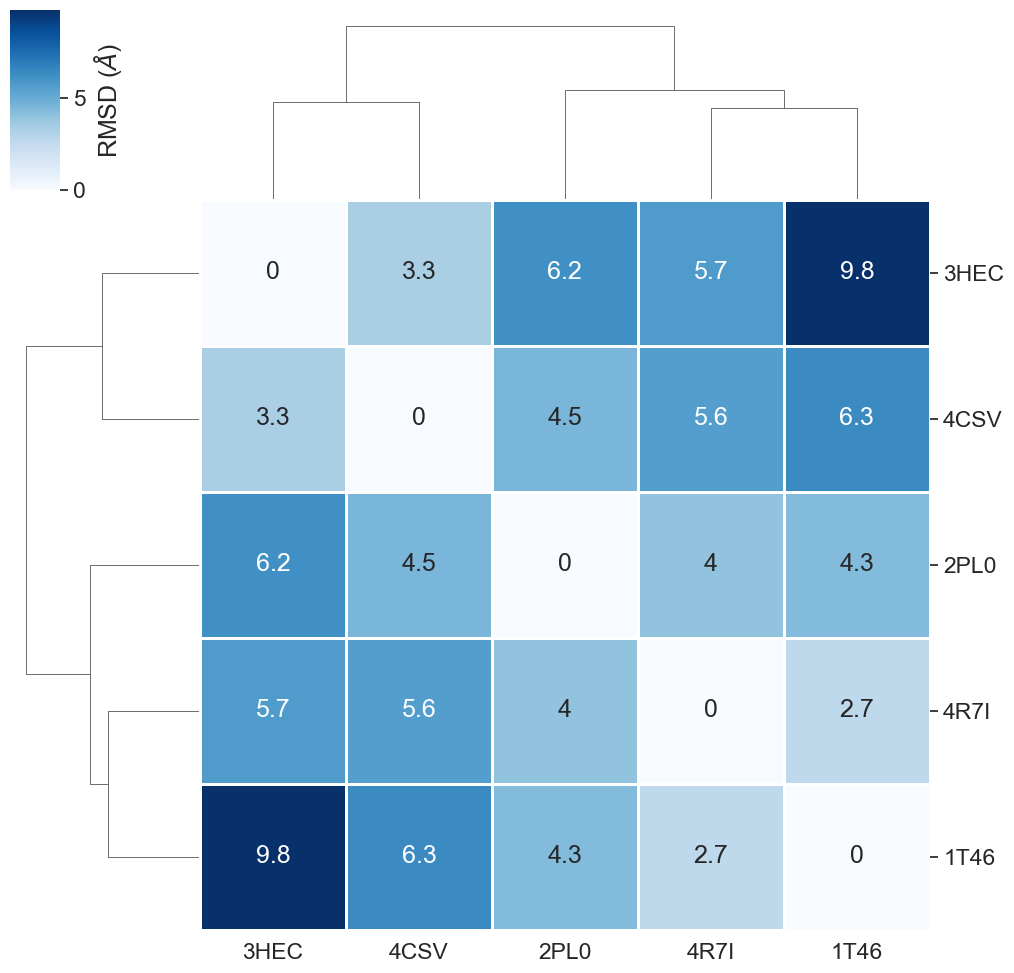

In [57]:
plot_clustermap(filtered_rmsd_matrix_bs);

好多了！

## 讨论

在本教程中，我们使用了一种简单的比较方法，即基于结合位点区域序列对齐的结构叠加，然后进行 RMSD 计算，以识别 Imatinib 的可能脱靶。我们能够将 NQO2 识别为异常值。

我们可以使用的另一个分析是查看原子级结合位点特征之间的相似性，例如在 TeachOpenCADD 激酶教程（**T023-T028**）中介绍的 KiSSim 指纹。此外，我们可以使用几何方法进行结合位点比较，如 **T015** 和 **T016** 中讨论的对接方法。